In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

Text(0, 0.5, 'Conductivite thermique (W/m/K)')

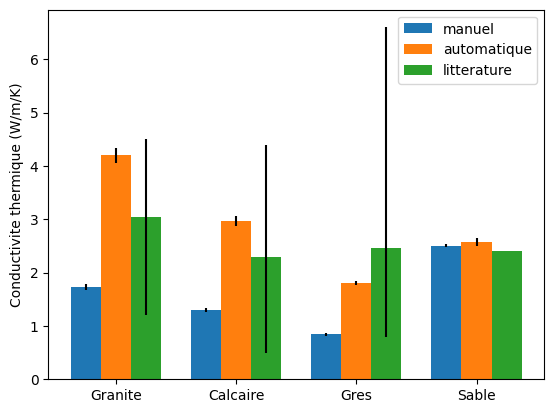

In [2]:
# [granite, calcaire, gres, sable]
manuel = [1.73,1.3,0.841,2.507]
merr = [0.06,0.038,0.032,0.024]
automatique = [4.2,2.97,1.81,2.57]
aerr = [0.14,0.1,0.04,0.08]
litterature = [3.05,2.29,2.47,2.402]
lerr_lower = [1.85,1.79,1.67,0]
lerr_upper = [1.45,2.11,4.13,0]
fig, ax = plt.subplots()
#position en x, valeur y, erreur, largeur, label
ax.bar([0.1,0.5,0.9,1.3],manuel,yerr=merr, width=0.1, label='manuel')
ax.bar([0.2,0.6,1,1.4],automatique, yerr=aerr,width=0.1, label ='automatique')
ax.bar([0.3,0.7,1.1,1.5],litterature,yerr=[lerr_lower,lerr_upper], width=0.1, label ='litterature')
ax.legend()

# axe x
ax.set_xticks([0.2, 0.6, 1, 1.4])
ax.set_xticklabels(['Granite', 'Calcaire', 'Gres', 'Sable'])
ax.set_ylabel("Conductivite thermique (W/m/K)")

#plt.savefig("C:/Users/Nicolas Onillon/PycharmProjects/TP_geologie/hist_thermique.eps")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


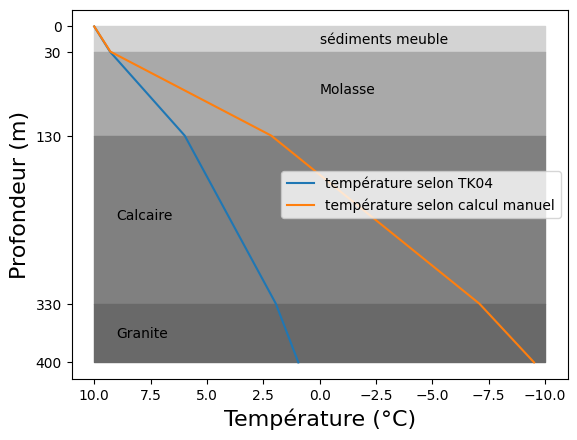

In [53]:
depth = [0, 30, 130, 330,400]
# gradient en K/m
kmeuble, kmolasse, kcalcaire, kgranite = 2.57, 1.81, 2.97, 4.2
kmeubleman, kmolasseman, kcalcaireman, kgraniteman = 2.507, 0.841, 1.3, 1.73
heat = 0.06 # w/m2
grad_meuble, grad_molasse, grad_calcaire, grad_granite = -heat/kmeuble, -heat/kmolasse, -heat/kcalcaire, -heat/kgranite
grad_meubleman, grad_molasseman, grad_calcaireman, grad_graniteman = -heat/kmeubleman, -heat/kmolasseman, -heat/kcalcaireman, -heat/kgraniteman

#automatique
T = [10]
T.append(T[0]+(depth[1]-depth[0])*grad_meuble)
T.append(T[1]+(depth[2]-depth[1])*grad_molasse)
T.append(T[2]+(depth[3]-depth[2])*grad_calcaire)
T.append(T[3]+(depth[4]-depth[3])*grad_granite)

#manuel
Tm = [10]
Tm.append(Tm[0]+(depth[1]-depth[0])*grad_meubleman)
Tm.append(Tm[1]+(depth[2]-depth[1])*grad_molasseman)
Tm.append(Tm[2]+(depth[3]-depth[2])*grad_calcaireman)
Tm.append(Tm[3]+(depth[4]-depth[3])*grad_graniteman)

fig, ax = plt.subplots()
ax.plot(T,depth, label = 'température selon TK04')
ax.plot(Tm,depth, label = 'température selon calcul manuel')
ax.set_yticks(depth)
ax.legend()
ax.set_xlabel('Température (°C)',fontsize=16)
ax.set_ylabel('Profondeur (m)',fontsize=16)

#remplissage, x car horizontal
ax.fill_betweenx([depth[0], depth[1]], 10, -10, color='lightgray', label='Sédiments meubles')
ax.fill_betweenx([depth[1], depth[2]], 10, -10, color='darkgray', label='Molasse')
ax.fill_betweenx([depth[2], depth[3]], 10, -10, color='gray', label='Calcaire')
ax.fill_betweenx([depth[3], depth[4]], 10, -10, color='dimgray', label='Cristallin')

#texte
ax.text(0,20,'sédiments meuble')
ax.text(0,80,'Molasse')
ax.text(9,230,'Calcaire')
ax.text(9,370,'Granite')

#dans le bon sens
ax.invert_yaxis()
ax.invert_xaxis()

plt.savefig("C:/Users/Nicolas Onillon/PycharmProjects/TP_geologie/gradient.eps")